## Manual implementation of K-Means

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../Notebooks')
from Utilities import plot_settings
from scipy.stats import norm

In [15]:
np.random.seed(42)  # For reproducibility

# Helper function to generate rotated Gaussians
def generate_gaussian(mean, cov, n_samples):
    return np.random.multivariate_normal(mean, cov, n_samples)

# Define cluster centers and covariance matrices (elliptical + rotated)
clusters = [
    {"mean": [0.2, 0.2], "cov": [[0.01, 0.005], [0.005, 0.02]], "n": 3000},  # Elongated
    {"mean": [0.5, 0.5], "cov": [[0.02, -0.008], [-0.008, 0.015]], "n": 4000},  # Rotated
    {"mean": [0.6, 0.2], "cov": [[0.015, 0.0], [0.0, 0.01]], "n": 2000},  # Compact
    {"mean": [0.4, 0.7], "cov": [[0.012, 0.003], [0.003, 0.012]], "n": 2500},  # Spherical
]

# Generate clusters
data_list = []
label_list = []
for i, cluster in enumerate(clusters):
    points = generate_gaussian(cluster["mean"], cluster["cov"], cluster["n"])
    data_list.append(points)
    label_list.append(np.full(cluster["n"], i))

# Combine clusters
data = np.vstack(data_list)
true_labels = np.concatenate(label_list)

# Add noise points
noise = np.random.uniform(low=0.0, high=1.0, size=(500, 2))  # Uniform noise
data = np.vstack([data, noise])
true_labels = np.concatenate([true_labels, [-1]*len(noise)])  # Label noise as -1

Text(0, 0.5, 'Y')

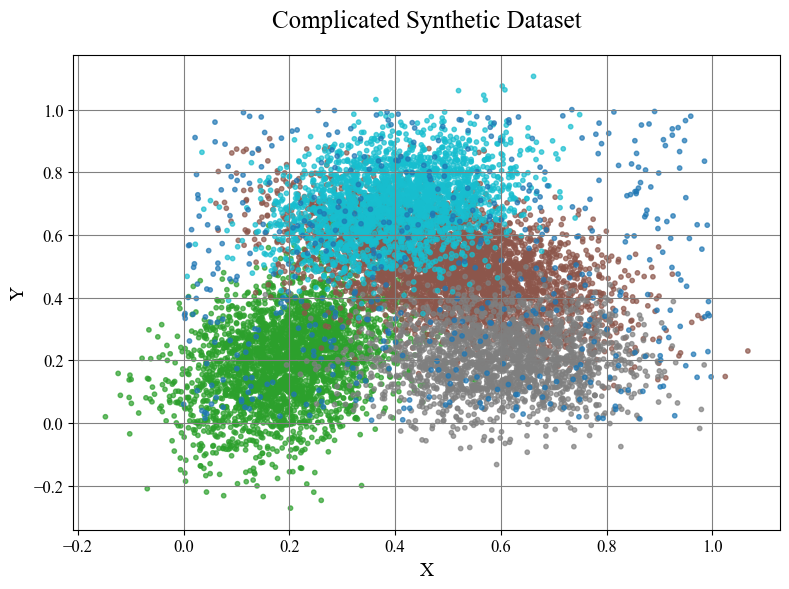

In [16]:
# Plot to visualize
plt.figure(figsize=(8, 6))
plt.scatter(data[:, 0], data[:, 1], c=true_labels, cmap='tab10', s=10, alpha=0.7)
plt.title("Complicated Synthetic Dataset")
plt.xlabel("X")
plt.ylabel("Y")

In [24]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
import numpy as np

# Assume data is (n_samples, n_features)
# If your data is (30000, 2), this approach works better when rows are feature vectors
# For correlation to make sense, each row should represent a variable (e.g., time series, profile)

# Step 1: Compute correlation distance matrix
corr_dist = pdist(data, metric='chebychev')  # 1 - Pearson correlation

# Step 2: Perform hierarchical clustering
Z = linkage(corr_dist, method='complete')  # You can use 'single', 'complete', 'ward' (ward only with Euclidean)

# Step 3: Optional - cut into flat clusters
labels = fcluster(Z, t=5, criterion='maxclust')

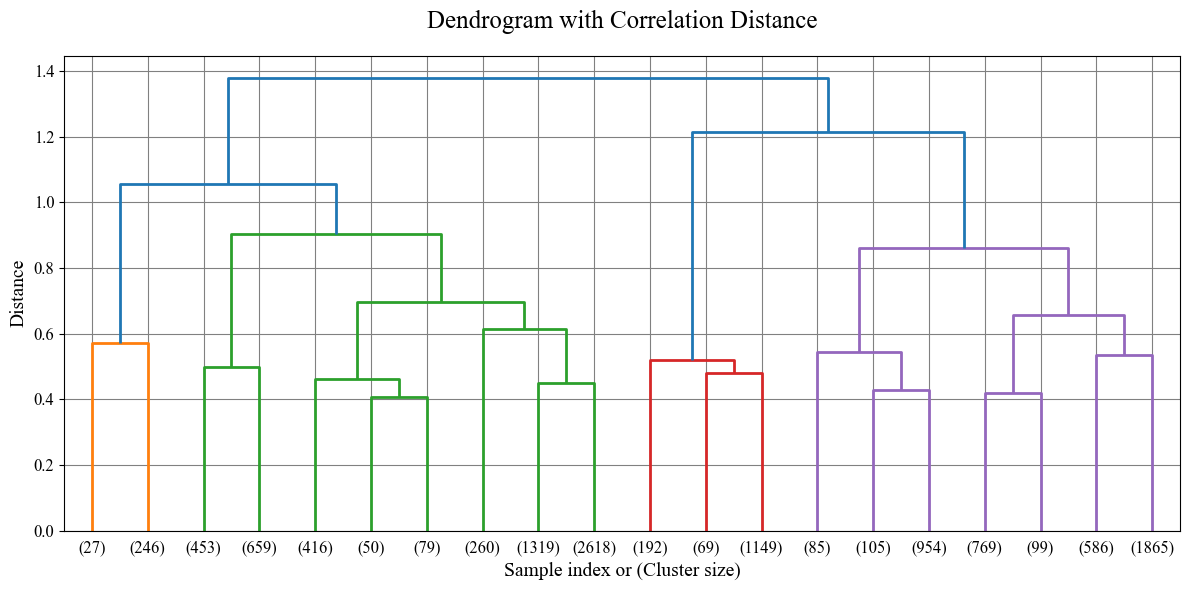

In [25]:
# Step 4: Dendrogram or scatter plot
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='lastp', p=20)
plt.title("Dendrogram with Correlation Distance")
plt.xlabel("Sample index or (Cluster size)")
plt.ylabel("Distance")
plt.show()

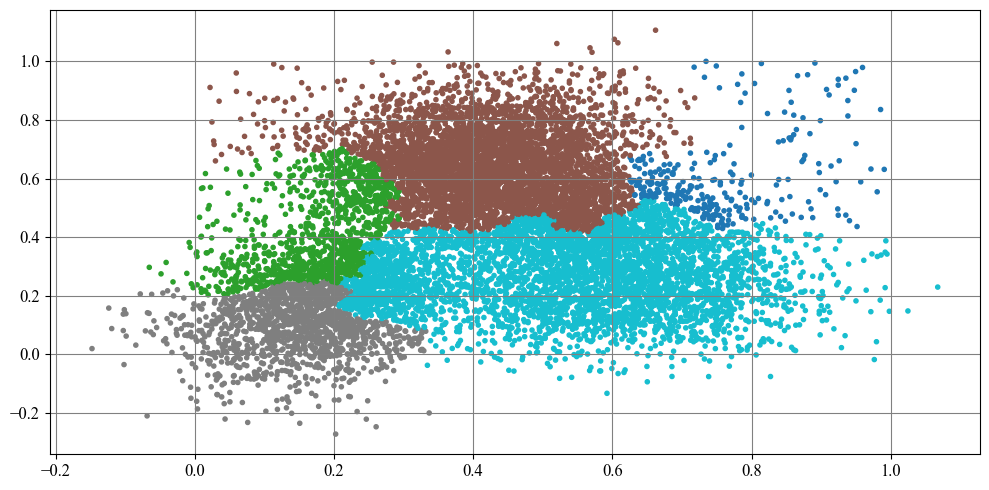

In [26]:
plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='tab10', marker='.')

Divide data and test set randomly

In [27]:
class Clusterizer:
    def __init__(self, n_clusters, data):
        self.n_clusters = n_clusters
        self.data = data
        self.mu = None
        self.labels = None
        self.train_data = None
        
    def train_test_split(self, data, test_size=0.2):
        """
        Split the data into training and test sets.
        
        Parameters:
        - data: The dataset to split.
        - test_size: Proportion of the dataset to include in the test split.
        
        Returns:
        - train_data: Training data.
        - test_data: Test data.
        """
        np.random.shuffle(data)
        split_index = int(len(data) * (1 - test_size))
        self.train_data = data[:split_index]
        self.test_data = data[split_index:]

    def fit(self):
        if self.train_data is None:
            self.train_test_split(self.data, test_size=0.2)
        indices = np.random.choice(self.train_data.shape[0], self.n_clusters, replace=False)
        self.mu = self.train_data[indices]
        
        # Initialize labels
        self.labels = np.zeros(self.train_data.shape[0], dtype=int)
        
        # Iterate until convergence
        while True:
            # Assign each point to the nearest cluster center
            for i, x in enumerate(self.train_data):
                distances = np.linalg.norm(x - self.mu, axis=1)
                self.labels[i] = np.argmin(distances)
            
            # Update cluster centers
            new_mu = np.array([self.train_data[self.labels == k].mean(axis=0) for k in range(self.n_clusters)])
            
            # Check for convergence
            if np.all(self.mu == new_mu):
                break
            
            self.mu = new_mu

    def predict(self, x):
        distances = np.linalg.norm(x - self.mu)
        return np.argmin(distances)

In [28]:
cl = Clusterizer(n_clusters=5, data=data)

In [29]:
cl.fit()

In [30]:
cl.mu

array([[0.63381725, 0.20078678],
       [0.56813295, 0.46489642],
       [0.19210122, 0.1718295 ],
       [0.4514777 , 0.75083764],
       [0.31068753, 0.55955525]])

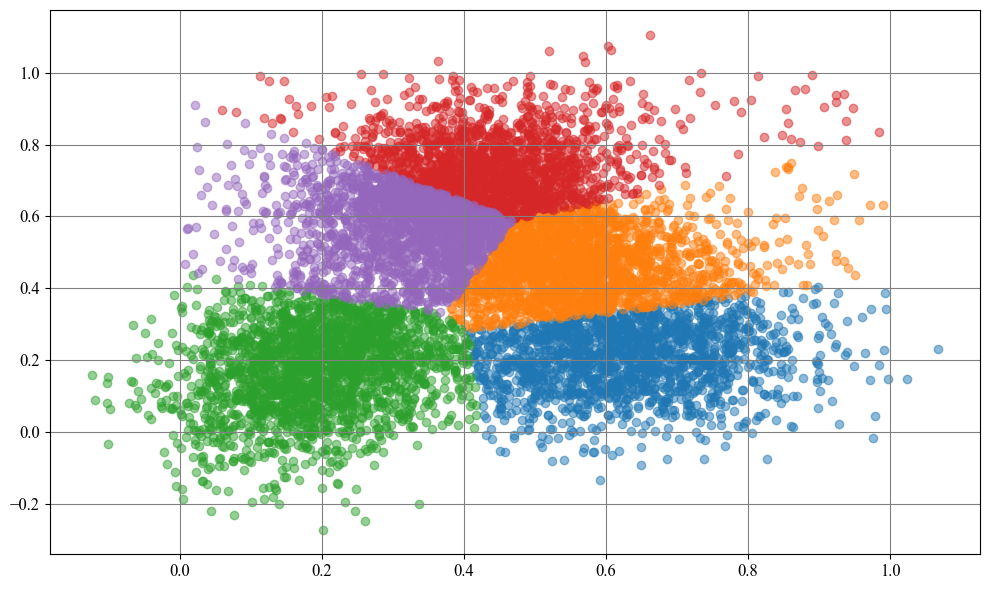

In [31]:
# Plot data points with predicted label color coding and cluster centers

plt.figure(figsize=(10, 6))
for i in range(cl.n_clusters):
    train_labels = cl.labels == i
    cluster_data = cl.train_data[cl.labels == i]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], alpha=0.5, label=f'Cluster {i+1}')

In [32]:
from sklearn.cluster import AgglomerativeClustering

In [33]:
model = AgglomerativeClustering(n_clusters=5, linkage='complete')  # 'single', 'complete', 'average', 'ward'
labels = model.fit_predict(data)

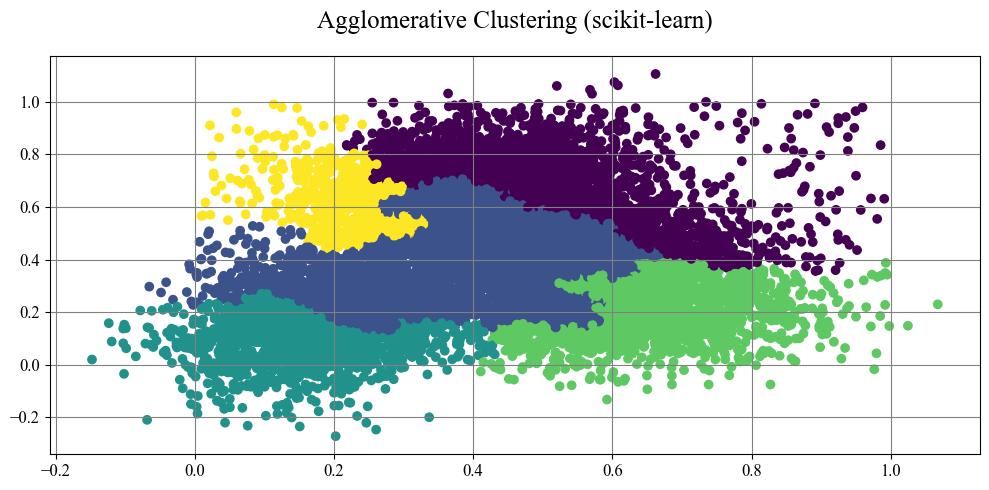

In [34]:
plt.scatter(data[:, 0], data[:, 1], c=labels)
plt.title("Agglomerative Clustering (scikit-learn)")
plt.grid(True)
plt.show()